In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse
from collections import defaultdict

In [4]:
sandbox_df = pd.read_csv('../data/raw/august_2024_uk_subreddits.csv')

In [5]:
sandbox_df.head()

,id,created_utc,subreddit,title,selftext,score,num_comments,url
0,1eh2jmf,1.722471e+09,unitedkingdom,One part of tipping culture we should keep,[removed],1,0,https://www.reddit.com/r/unitedkingdom/comment...
1,1eh2nw8,1.722471e+09,unitedkingdom,"Fast-Track to $10,000: The Easiest Ways to Ear...",[removed],1,0,https://www.reddit.com/r/unitedkingdom/comment...
2,1eh2paw,1.722471e+09,uknews,"""boy"" of 17.","This is a man, not a boy. Throw the book at hi...",1,8,https://www.reddit.com/r/uknews/comments/1eh2p...
3,1eh2psa,1.722471e+09,policeuk,Drone Image of Southport Riot - New Public Ord...,NaN,243,88,https://i.redd.it/67dqlotc2yfd1.jpeg
4,1eh2u4b,1.722471e+09,ukpolitics,"Fast-Track to $10,000: The Easiest Ways to Ear...",[removed],1,0,https://www.reddit.com/r/ukpolitics/comments/1...


## Initial integrity check

- 10,249 posts for one month
- num_comments and score are int - good
- 6048 missing values in selftext - the column that contains the contents of the post. Bad - 59%

In [6]:
# check num rows/cols
sandbox_df.shape

(10249, 8)

In [7]:
# check data types of cols
sandbox_df.dtypes

id                  str
created_utc     float64
subreddit           str
title               str
selftext            str
score             int64
num_comments      int64
url                 str
dtype: object

In [8]:
# null values check
null_vals = sandbox_df.isnull().sum()
null_vals

id                 0
created_utc        0
subreddit          0
title              0
selftext        6048
score              0
num_comments       0
url              156
dtype: int64

In [9]:
# proportion null
null_vals/sandbox_df.shape[0]

id              0.000000
created_utc     0.000000
subreddit       0.000000
title           0.000000
selftext        0.590106
score           0.000000
num_comments    0.000000
url             0.015221
dtype: float64

## Class balances

In [10]:
# check subreddit counts
subr_counts = sandbox_df['subreddit'].value_counts()
subr_counts

subreddit
unitedkingdom    5625
ukpolitics       2074
policeuk          832
LabourUK          680
uknews            627
reformuk          277
tories             75
brexit             57
gbnews              2
Name: count, dtype: int64

In [11]:
# check for subreddit imbalances
subr_counts/sandbox_df.shape[0]

subreddit
unitedkingdom    0.548834
ukpolitics       0.202361
policeuk         0.081179
LabourUK         0.066348
uknews           0.061177
reformuk         0.027027
tories           0.007318
brexit           0.005562
gbnews           0.000195
Name: count, dtype: float64

## Stats for virality

In [12]:
# descriptive stats
virality_cols_df = sandbox_df.loc[:, ['num_comments', 'score']]

virality_cols_df.describe()

,num_comments,score
count,10249.000000,10249.000000
mean,42.542492,51.729730
std,136.178918,185.324393
min,0.000000,0.000000
25%,0.000000,1.000000
50%,1.000000,1.000000
75%,20.000000,18.000000
max,3065.000000,6159.000000


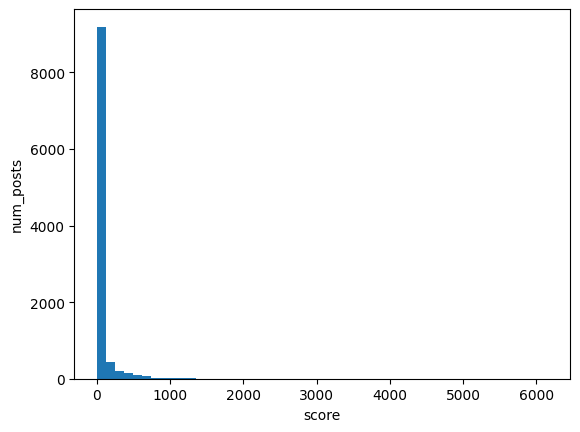

In [13]:
# Look at distribution of scores
plt.hist(virality_cols_df.loc[:, 'score'], bins=50)
plt.xlabel('score')
plt.ylabel('num_posts')
plt.show()

Vast majority of reddit posts have a score of <100. Big positive skew. Likely to need log transformed score for models

NB - score = num up votes - num down votes

In [14]:
# View top 10 highest scoring posts of the month 

sorted_by_score = sandbox_df.sort_values(by=['score'], ascending=False)
sorted_by_score.iloc[:10, :]

,id,created_utc,subreddit,title,selftext,score,num_comments,url
1860,1eku5df,1.722880e+09,uknews,Sky News journalist forced off air by muslim p...,NaN,6159,140,https://v.redd.it/l6u1z68quvgd1
3030,1en0txs,1.723106e+09,uknews,England gets tired of fascists having a tantru...,Is this the end of the riots?,4576,1213,https://www.nbcnews.com/news/world/london-high...
2630,1em8rtq,1.723028e+09,uknews,Nigel Farage Has Admitted Spreading Misinforma...,Surely this should be against ministerial rules?,4093,522,https://www.huffingtonpost.co.uk/entry/nigel-f...
6331,1ev5nc1,1.723975e+09,uknews,Misogyny to be treated as extremism by UK gove...,NaN,4077,1336,https://www.bbc.co.uk/news/articles/c15gn0lq7p5o
6899,1ewqwk5,1.724145e+09,unitedkingdom,What happened to this subreddit?,Two years ago this sub was memed on for how le...,3360,1916,https://www.reddit.com/r/unitedkingdom/comment...
5180,1erwapy,1.723624e+09,uknews,Liz Truss storms off stage after humiliating l...,[https://www.mirror.co.uk/news/politics/liz-tr...,3201,573,https://www.reddit.com/r/uknews/comments/1erwa...
148,1ehehto,1.722512e+09,uknews,Boy charged with Southport stabbing murders na...,NaN,2963,2082,https://www.liverpoolecho.co.uk/news/liverpool...
946,1ej5io2,1.722698e+09,uknews,Muslim stabbed at train station hours before f...,NaN,2870,1232,https://metro.co.uk/2024/08/02/muslim-stabbed-...
1556,1ekgv2y,1.722839e+09,uknews,Conservatives left UK wide open to far-right v...,NaN,2579,891,https://www.theguardian.com/uk-news/article/20...
2386,1elpvrr,1.722970e+09,uknews,Mindless UK riot thugs could be thrown in pris...,[https://www.mirror.co.uk/news/politics/uk-rio...,2183,775,https://www.reddit.com/r/uknews/comments/1elpv...


## Text length

Title/body word counts and length stats. Useful to know for BERT classifier - has mac token limit of 512

In [15]:
sandbox_df['title_length'] = sandbox_df.loc[:, 'title'].str.split().str.len()
sandbox_df['body_length'] = sandbox_df.loc[:, 'selftext'].str.split().str.len()
sandbox_df

,id,created_utc,subreddit,title,selftext,score,num_comments,url,title_length,body_length
0,1eh2jmf,1.722471e+09,unitedkingdom,One part of tipping culture we should keep,[removed],1,0,https://www.reddit.com/r/unitedkingdom/comment...,8,1.0
1,1eh2nw8,1.722471e+09,unitedkingdom,"Fast-Track to $10,000: The Easiest Ways to Ear...",[removed],1,0,https://www.reddit.com/r/unitedkingdom/comment...,12,1.0
2,1eh2paw,1.722471e+09,uknews,"""boy"" of 17.","This is a man, not a boy. Throw the book at hi...",1,8,https://www.reddit.com/r/uknews/comments/1eh2p...,3,34.0
3,1eh2psa,1.722471e+09,policeuk,Drone Image of Southport Riot - New Public Ord...,NaN,243,88,https://i.redd.it/67dqlotc2yfd1.jpeg,11,NaN
4,1eh2u4b,1.722471e+09,ukpolitics,"Fast-Track to $10,000: The Easiest Ways to Ear...",[removed],1,0,https://www.reddit.com/r/ukpolitics/comments/1...,12,1.0
...,...,...,...,...,...,...,...,...,...,...
10244,1f604rs,1.725146e+09,unitedkingdom,UC claim review,[removed],1,0,https://www.reddit.com/r/unitedkingdom/comment...,3,1.0
10245,1f609lh,1.725146e+09,policeuk,Concern for welfare...who's responsible?,This is a *frustrated at being sent round in c...,1,9,https://www.reddit.com/r/policeuk/comments/1f6...,4,558.0
10246,1f60uhs,1.725148e+09,unitedkingdom,:Accrington: Police tobacco sales fears over l...,NaN,1,16,https://www.lancashiretelegraph.co.uk/news/245...,10,NaN
10247,1f6166d,1.725149e+09,unitedkingdom,Please someone help im strugling here,[removed],1,1,https://www.reddit.com/r/unitedkingdom/comment...,6,1.0


In [16]:
sandbox_df.loc[:, ['title_length', 'body_length']].describe()

,title_length,body_length
count,10249.000000,4201.000000
mean,10.429213,32.740538
std,6.899601,106.924035
min,1.000000,0.000000
25%,6.000000,1.000000
50%,10.000000,1.000000
75%,13.000000,6.000000
max,65.000000,2165.000000


Merge title and body texts into single string. Anything with no selftext gets null replaced with an empty string. 

In [17]:
sandbox_df['selftext'] = sandbox_df['selftext'].str.replace(r'\[removed\]|\[deleted\]', '', regex=True)

In [18]:
sandbox_df['combined_text'] = sandbox_df['title'].str.cat(sandbox_df['selftext'], sep='', na_rep='')
sandbox_df

,id,created_utc,subreddit,title,selftext,score,num_comments,url,title_length,body_length,combined_text
0,1eh2jmf,1.722471e+09,unitedkingdom,One part of tipping culture we should keep,,1,0,https://www.reddit.com/r/unitedkingdom/comment...,8,1.0,One part of tipping culture we should keep
1,1eh2nw8,1.722471e+09,unitedkingdom,"Fast-Track to $10,000: The Easiest Ways to Ear...",,1,0,https://www.reddit.com/r/unitedkingdom/comment...,12,1.0,"Fast-Track to $10,000: The Easiest Ways to Ear..."
2,1eh2paw,1.722471e+09,uknews,"""boy"" of 17.","This is a man, not a boy. Throw the book at hi...",1,8,https://www.reddit.com/r/uknews/comments/1eh2p...,3,34.0,"""boy"" of 17.This is a man, not a boy. Throw th..."
3,1eh2psa,1.722471e+09,policeuk,Drone Image of Southport Riot - New Public Ord...,NaN,243,88,https://i.redd.it/67dqlotc2yfd1.jpeg,11,NaN,Drone Image of Southport Riot - New Public Ord...
4,1eh2u4b,1.722471e+09,ukpolitics,"Fast-Track to $10,000: The Easiest Ways to Ear...",,1,0,https://www.reddit.com/r/ukpolitics/comments/1...,12,1.0,"Fast-Track to $10,000: The Easiest Ways to Ear..."
...,...,...,...,...,...,...,...,...,...,...,...
10244,1f604rs,1.725146e+09,unitedkingdom,UC claim review,,1,0,https://www.reddit.com/r/unitedkingdom/comment...,3,1.0,UC claim review
10245,1f609lh,1.725146e+09,policeuk,Concern for welfare...who's responsible?,This is a *frustrated at being sent round in c...,1,9,https://www.reddit.com/r/policeuk/comments/1f6...,4,558.0,Concern for welfare...who's responsible?This i...
10246,1f60uhs,1.725148e+09,unitedkingdom,:Accrington: Police tobacco sales fears over l...,NaN,1,16,https://www.lancashiretelegraph.co.uk/news/245...,10,NaN,:Accrington: Police tobacco sales fears over l...
10247,1f6166d,1.725149e+09,unitedkingdom,Please someone help im strugling here,,1,1,https://www.reddit.com/r/unitedkingdom/comment...,6,1.0,Please someone help im strugling here


In [19]:
# check length of combined text
sandbox_df['combined_text_length'] = sandbox_df.loc[:, 'combined_text'].str.split().str.len()
sandbox_df['combined_text_length'].describe()

count    10249.000000
mean        23.464143
std         70.182246
min          1.000000
25%          7.000000
50%         11.000000
75%         15.000000
max       2191.000000
Name: combined_text_length, dtype: float64

If using words as tokens, the majority of posts will fall below the BERT token limit

## Domain Profiling

Extract the core base domains (e.g., bbc.co.uk, theguardian.com) from raw url column - useful for weak supervision labelling

Big mix of outlets (all of the main ones you'd expect to see)

In [20]:
# use urlparse to get domains out of urls
sandbox_df['domains'] = sandbox_df['url'].fillna('').astype(str).apply(lambda x: urlparse(x).netloc).str.replace('www.', '')
sandbox_df

,id,created_utc,subreddit,title,selftext,score,num_comments,url,title_length,body_length,combined_text,combined_text_length,domains
0,1eh2jmf,1.722471e+09,unitedkingdom,One part of tipping culture we should keep,,1,0,https://www.reddit.com/r/unitedkingdom/comment...,8,1.0,One part of tipping culture we should keep,8,reddit.com
1,1eh2nw8,1.722471e+09,unitedkingdom,"Fast-Track to $10,000: The Easiest Ways to Ear...",,1,0,https://www.reddit.com/r/unitedkingdom/comment...,12,1.0,"Fast-Track to $10,000: The Easiest Ways to Ear...",12,reddit.com
2,1eh2paw,1.722471e+09,uknews,"""boy"" of 17.","This is a man, not a boy. Throw the book at hi...",1,8,https://www.reddit.com/r/uknews/comments/1eh2p...,3,34.0,"""boy"" of 17.This is a man, not a boy. Throw th...",36,reddit.com
3,1eh2psa,1.722471e+09,policeuk,Drone Image of Southport Riot - New Public Ord...,NaN,243,88,https://i.redd.it/67dqlotc2yfd1.jpeg,11,NaN,Drone Image of Southport Riot - New Public Ord...,11,i.redd.it
4,1eh2u4b,1.722471e+09,ukpolitics,"Fast-Track to $10,000: The Easiest Ways to Ear...",,1,0,https://www.reddit.com/r/ukpolitics/comments/1...,12,1.0,"Fast-Track to $10,000: The Easiest Ways to Ear...",12,reddit.com
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10244,1f604rs,1.725146e+09,unitedkingdom,UC claim review,,1,0,https://www.reddit.com/r/unitedkingdom/comment...,3,1.0,UC claim review,3,reddit.com
10245,1f609lh,1.725146e+09,policeuk,Concern for welfare...who's responsible?,This is a *frustrated at being sent round in c...,1,9,https://www.reddit.com/r/policeuk/comments/1f6...,4,558.0,Concern for welfare...who's responsible?This i...,561,reddit.com
10246,1f60uhs,1.725148e+09,unitedkingdom,:Accrington: Police tobacco sales fears over l...,NaN,1,16,https://www.lancashiretelegraph.co.uk/news/245...,10,NaN,:Accrington: Police tobacco sales fears over l...,10,lancashiretelegraph.co.uk
10247,1f6166d,1.725149e+09,unitedkingdom,Please someone help im strugling here,,1,1,https://www.reddit.com/r/unitedkingdom/comment...,6,1.0,Please someone help im strugling here,6,reddit.com


In [21]:
domain_counts = sandbox_df['domains'].value_counts()
domain_counts

domains
reddit.com                                      3452
bbc.co.uk                                        773
i.redd.it                                        692
theguardian.com                                  692
telegraph.co.uk                                  282
                                                ... 
tptimes.org                                        1
ladyfreethinker.org                                1
ivycraftscottage.etsy.com                          1
jobs.southessex.ac.uk                              1
internationalnewsandstories4748.blogspot.com       1
Name: count, Length: 599, dtype: int64

Want to see how data is distributed across political specturm (for political leaning label). Use https://mediabiasfactcheck.com/ to categorise the top 25 domains in the data. 

Very useful website for both political leaning and misinformation signals that you can get from the domain. 

For now, I'll look up the following fields for each of the domains:
- `bias` - ideological indicator
- `country` - geographic filter - interesting to see geographical spread of outlets publishing about UK politics/news
- `reporting` - factual quality scale, outlet's history of factually accurate reporting
- `credibility` - overall trust metric. 


Can use these to write LFs for both my validity/veracity label and my political bias label

In [22]:
top_25_domains = domain_counts[:25].index.tolist()
top_25_domains

['reddit.com',
 'bbc.co.uk',
 'i.redd.it',
 'theguardian.com',
 'telegraph.co.uk',
 'bbc.com',
 'news.sky.com',
 'x.com',
 'youtube.com',
 'youtu.be',
 'independent.co.uk',
 'thetimes.com',
 '',
 'inews.co.uk',
 'mirror.co.uk',
 'dailymail.co.uk',
 'usabestbusiness.com',
 'ft.com',
 'metro.co.uk',
 'standard.co.uk',
 'v.redd.it',
 'itv.com',
 'lbc.co.uk',
 'express.co.uk',
 'politico.eu']

Only a small set for now so hard-coding a dict of the required MBFC categories for each domain 

In [24]:

mbfc_mapping = {
    # Internal Platform 
    "reddit.com": {"bias": "Platform/Abstain", "reporting": "Abstain", "credibility": "Abstain"},
    "i.redd.it": {"bias": "Platform/Abstain", "reporting": "Abstain", "credibility": "Abstain"},
    "v.redd.it": {"bias": "Platform/Abstain", "reporting": "Abstain", "credibility": "Abstain"},
    "": {"bias": "Abstain", "reporting": "Abstain", "credibility": "Abstain"},
    
    # Social Media
    "x.com": {"bias": "Unfiltered/Abstain", "reporting": "Low", "credibility": "Low"},
    "youtube.com": {"bias": "Unfiltered/Abstain", "reporting": "Mixed", "credibility": "Medium"},
    "youtu.be": {"bias": "Unfiltered/Abstain", "reporting": "Mixed", "credibility": "Medium"},
    
    # Left / Left-Center Outlets
    "theguardian.com": {"bias": "Left-Center", "reporting": "High", "credibility": "High"},
    "independent.co.uk": {"bias": "Left-Center", "reporting": "High", "credibility": "High"},
    "mirror.co.uk": {"bias": "Left-Center", "reporting": "High", "credibility": "High"},
    
    # --- Right / Right-Center Outlets ---
    "telegraph.co.uk": {"bias": "Right-Center", "reporting": "High", "credibility": "High"},
    "thetimes.com": {"bias": "Right-Center", "reporting": "High", "credibility": "High"},
    "dailymail.co.uk": {"bias": "Right", "reporting": "Mixed", "credibility": "Medium/Low"},
    "express.co.uk": {"bias": "Right", "reporting": "Mixed", "credibility": "Medium/Low"},
    
    # Center / Least Biased Outlets
    "bbc.co.uk": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "bbc.com": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "news.sky.com": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "ft.com": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "inews.co.uk": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "standard.co.uk": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "metro.co.uk": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "itv.com": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "lbc.co.uk": {"bias": "Center", "reporting": "High", "credibility": "High"},
    "politico.eu": {"bias": "Center", "reporting": "High", "credibility": "High"},
    
    # Questionable / Spam / Clickbait
    "usabestbusiness.com": {"bias": "Questionable", "reporting": "Low", "credibility": "Low"}
}


In [27]:
# Add columns with MBFC ratings
sandbox_df['political_bias'] = sandbox_df['domains'].apply(lambda x: mbfc_mapping.get(x, {}).get('bias', 'Abstain/Unknown'))
sandbox_df['reporting_quality'] = sandbox_df['domains'].apply(lambda x: mbfc_mapping.get(x, {}).get('reporting', 'Abstain/Unknown'))
sandbox_df['credibility'] = sandbox_df['domains'].apply(lambda x: mbfc_mapping.get(x, {}).get('credibility', 'Abstain/Unknown'))

# Crosstab subreddits with political bias 
pd.crosstab(sandbox_df['subreddit'], sandbox_df['political_bias'])

political_bias,Abstain,Abstain/Unknown,Center,Left-Center,Platform/Abstain,Questionable,Right,Right-Center,Unfiltered/Abstain
subreddit,,,,,,,,,
LabourUK,6,241,105,127,156,0,7,20,18
brexit,1,13,8,11,18,0,0,2,4
gbnews,0,0,0,0,1,0,0,0,1
policeuk,9,19,21,7,751,0,5,3,17
reformuk,4,25,9,2,205,0,3,5,24
tories,1,18,5,4,31,0,1,6,9
uknews,14,216,128,72,153,0,10,12,22
ukpolitics,23,416,431,305,461,0,41,210,187
unitedkingdom,102,852,1103,485,2423,96,74,185,305


Step 3: The Cross-Tabulation Matrix (The Polarization Check)
This is the most critical analytical step to prove whether your dataset is politically segregated. You want to see who is sharing what.

Generate a contingency table or a cross-tabulation matrix that matches your subreddits against your categorized ideological domains (Left vs. Right vs. Neutral).

Analyze the density: Do users in general spaces share an equal mix of Left and Right media? Do users in right-wing subreddits completely reject left-wing media domains (and vice versa)? This matrix visually maps the boundaries of polarization in your sandbox data.

Step 4: Text Style and Length Analysis Across Ideologies
Different political ecosystems often communicate using entirely different lexical styles, titles, and emotional weights.

Compute the character or word counts for both titles and body text across your data.

Group these length statistics by your ideological anchors. Check if one side of the spectrum relies more heavily on short, punchy, reactive titles, or if another side features massive, long-form text essays in their submissions. This establishes whether document length will be a confounding variable for your future BERT layers.

Step 5: Profile Engagement Metrics (The Virality Control Baseline)
To lay the groundwork for your future predictive models, you need to know if political ideology correlates with how fast or how widely a post spreads.

Calculate the summary statistics (mean, median, and max) for score (upvotes) and num_comments, grouped by political alignment.

Look for systemic differences: Do right-wing news articles get higher comment volumes but fewer upvotes? Does neutral news (like the BBC) receive steady, predictable engagement while partisan news shows massive, explosive spikes?